In [4]:
!pip install ptflops

✅ Classes Detected: ['AD', 'CN', 'MCI']
📊 30:70 Split - Train: 1391 | Test: 3608
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 117MB/s] 


Epoch [1/50] - Loss: 0.8795
Epoch [5/50] - Loss: 0.0799
Epoch [10/50] - Loss: 0.0384
Epoch [15/50] - Loss: 0.0188
Epoch [20/50] - Loss: 0.0150
Epoch [25/50] - Loss: 0.0123
Epoch [35/50] - Loss: 0.0019
Epoch [40/50] - Loss: 0.0025
Epoch [45/50] - Loss: 0.0004
Epoch [50/50] - Loss: 0.0100

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 FINAL REPORT: 30:70 RATIO
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
GFLOPs: 5.38 GMac | Input: 300x300
Overall Accuracy: 0.9504
Overall ROC-AUC:  0.9947
F1-Score: 0.9500 | Precision: 0.9509 | Recall: 0.9504
------------------------------------------------------------
Accuracy for AD: 0.9403
Accuracy for CN: 0.8938
Accuracy for MCI: 0.9862
------------------------------------------------------------
Training Time: 1154.38s | Testing Time: 35.55s


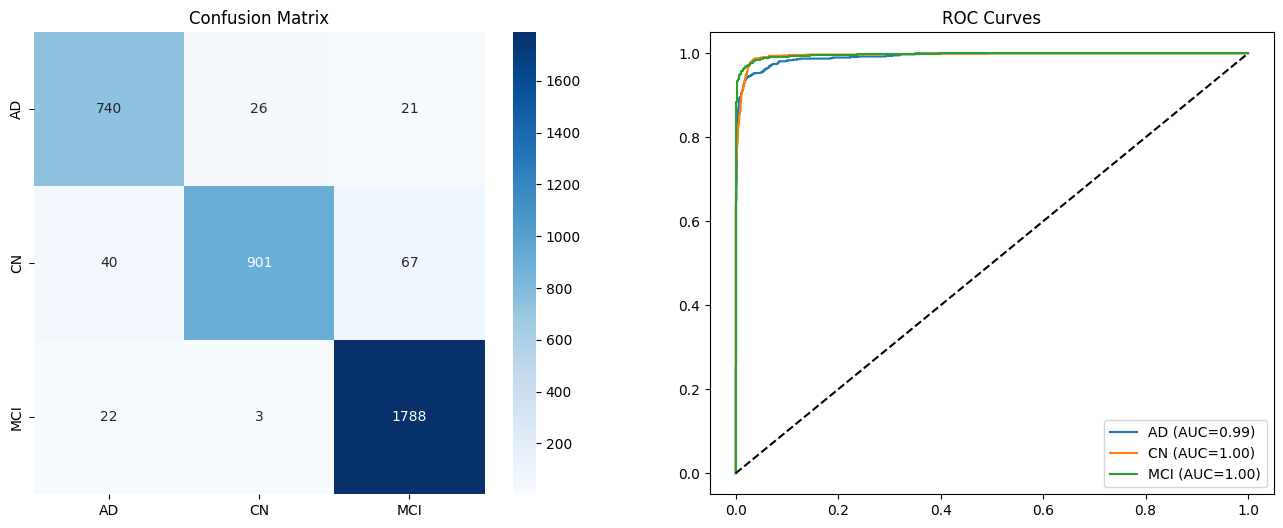

In [5]:
# 1. INSTALL NECESSARY LIBRARIES
!pip install ptflops --quiet

import os, time, torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from torch.utils.data import DataLoader, Subset, ConcatDataset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, 
                             roc_auc_score, confusion_matrix, roc_curve, auc)
from ptflops import get_model_complexity_info

# 2. SET RATIO & PATHS
TRAIN_RATIO = 0.30  # <--- Updated for 30:70
TEST_RATIO = 0.70

# Ensure these point to the folders containing AD, CN, MCI
train_dir = '/kaggle/input/datasets/kushanknath/alzheimer-dataset/Alzheimer__disease/train-20260216T155907Z-1-001/train'
test_dir  = '/kaggle/input/datasets/kushanknath/alzheimer-dataset/Alzheimer__disease/test-20260216T155809Z-1-001/test'

# 3. CONFIGURATION
BATCH_SIZE = 32
EPOCHS = 50         # Reduced to 30 to prevent overfitting and save time
IMG_SIZE = 300     
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 4. DATA PREPARATION (Leakage-Proof & Stratified)
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load both to get all available images
ds1 = datasets.ImageFolder(train_dir, transform=transform)
ds2 = datasets.ImageFolder(test_dir, transform=transform)
full_dataset = ConcatDataset([ds1, ds2])

# Extract labels
labels = np.array(ds1.targets + ds2.targets)
indices = np.arange(len(full_dataset))

# Perform 30:70 Stratified Split
# This ensures AD, CN, and MCI are balanced in both sets
train_idx, test_idx = train_test_split(
    indices, 
    train_size=TRAIN_RATIO, 
    stratify=labels, 
    random_state=42
)

# Further split 10% of train for validation
train_labels_sub = labels[train_idx]
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.10, stratify=train_labels_sub, random_state=42
)

loaders = {
    'train': DataLoader(Subset(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True),
    'val':   DataLoader(Subset(full_dataset, val_idx), batch_size=BATCH_SIZE),
    'test':  DataLoader(Subset(full_dataset, test_idx), batch_size=BATCH_SIZE)
}

print(f"✅ Classes Detected: {ds1.classes}")
print(f"📊 30:70 Split - Train: {len(train_idx)} | Test: {len(test_idx)}")

# 5. MODEL (EfficientNet-V2S)
model = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 3) 
model = model.to(DEVICE)

# 6. GFLOPs (Complexity)
macs, params = get_model_complexity_info(model, (3, IMG_SIZE, IMG_SIZE), as_strings=True, print_per_layer_stat=False)

# 7. TRAINING
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
start_train_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, lbls in loaders['train']:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {running_loss/len(loaders['train']):.4f}")

train_wall_clock = time.time() - start_train_time

# 8. EVALUATION
model.eval()
y_true, y_pred, y_probs = [], [], []
start_test_time = time.time()
with torch.no_grad():
    for imgs, lbls in loaders['test']:
        outputs = model(imgs.to(DEVICE))
        y_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
        y_pred.extend(outputs.argmax(1).cpu().numpy())
        y_true.extend(lbls.numpy())
test_wall_clock = time.time() - start_test_time

y_true, y_pred, y_probs = np.array(y_true), np.array(y_pred), np.array(y_probs)
all_labels = [0, 1, 2]
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', labels=all_labels)
cm = confusion_matrix(y_true, y_pred, labels=all_labels)
overall_roc_auc = roc_auc_score(y_true, y_probs, multi_class='ovr', labels=all_labels)

# 9. FINAL OUTPUT
print("\n" + "★"*60)
print(f" FINAL REPORT: {int(TRAIN_RATIO*100)}:{int(TEST_RATIO*100)} RATIO")
print("★"*60)
print(f"GFLOPs: {macs} | Input: {IMG_SIZE}x{IMG_SIZE}")
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Overall ROC-AUC:  {overall_roc_auc:.4f}")
print(f"F1-Score: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
print("-" * 60)
for i, name in enumerate(ds1.classes):
    acc = cm[i,i] / cm[i,:].sum() if cm[i,:].sum() > 0 else 0
    print(f"Accuracy for {name}: {acc:.4f}")
print("-" * 60)
print(f"Training Time: {train_wall_clock:.2f}s | Testing Time: {test_wall_clock:.2f}s")

# 10. VISUALIZATIONS
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ds1.classes, yticklabels=ds1.classes, ax=ax[0])
ax[0].set_title("Confusion Matrix")

for i in range(3):
    fpr, tpr, _ = roc_curve(y_true == i, y_probs[:, i])
    ax[1].plot(fpr, tpr, label=f'{ds1.classes[i]} (AUC={auc(fpr, tpr):.2f})')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title("ROC Curves")
ax[1].legend()
plt.show()